# Resume / Candidate Screening System

## Machine Learning Internship Task 3

### Developed By:
Shubham

### Objective:
Build a Machine Learning system to screen and rank resumes based on job descriptions and required skills.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [11]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Krishna\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Krishna\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Load Dataset

Loading the resume dataset.

In [12]:
df = pd.read_csv("C:/Users/Krishna/Downloads/Resume.csv")

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


# Dataset Information

Checking dataset shape, columns, and missing values.

In [9]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset: (2484, 4)

Columns:
Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB
None

Missing Values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


# Select Important Columns

Selecting resume text and category columns.

In [13]:
df = df[['Resume_str', 'Category']]

df.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


# Rename Columns

Renaming columns for simplicity.

In [14]:
df.columns = ['resume', 'category']

df.head()

,resume,category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


# Resume Category Visualization

Visualizing resume categories.

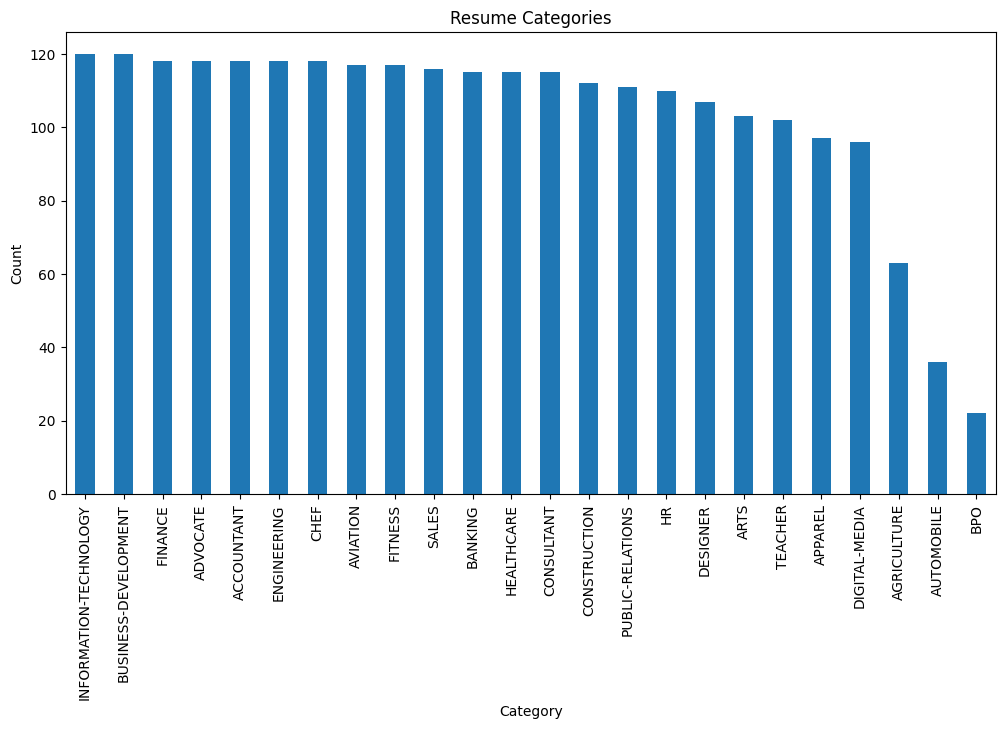

In [15]:
plt.figure(figsize=(12,6))

df['category'].value_counts().plot(kind='bar')

plt.title("Resume Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

# Text Cleaning

Cleaning and preprocessing resume text.

In [16]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    
    text = str(text).lower()
    
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    words = word_tokenize(text)
    
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

df['clean_resume'] = df['resume'].apply(clean_text)

df.head()

,resume,category,clean_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,HR,hr director summary years experience recruitin...
3,HR SPECIALIST Summary Dedica...,HR,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,HR,hr manager skill highlights hr skills hr depar...


# Job Description

Creating a sample job description for candidate matching.

In [17]:
job_description = """
Looking for a Python Developer with knowledge of Machine Learning,
Data Analysis, SQL, Flask, and Scikit-learn.
"""

# TF-IDF Vectorization

Converting resumes and job descriptions into numerical vectors.

In [18]:
tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(
    df['clean_resume'].tolist() + [job_description]
)

# Resume Similarity Calculation

Calculating similarity between resumes and job description.

In [19]:
cosine_sim = cosine_similarity(
    tfidf_matrix[-1],
    tfidf_matrix[:-1]
)

similarity_scores = cosine_sim.flatten()

df['score'] = similarity_scores

df.head()

,resume,category,clean_resume,score
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,hr administrator marketing associate hr admini...,0.007290
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,hr specialist us hr operations summary versati...,0.001396
2,HR DIRECTOR Summary Over 2...,HR,hr director summary years experience recruitin...,0.001060
3,HR SPECIALIST Summary Dedica...,HR,hr specialist summary dedicated driven dynamic...,0.000000
4,HR MANAGER Skill Highlights ...,HR,hr manager skill highlights hr skills hr depar...,0.002471


# Candidate Ranking

Ranking resumes based on similarity score.

In [20]:
ranked_df = df.sort_values(by='score', ascending=False)

ranked_df[['category', 'score']].head(10)

,category,score
926,AGRICULTURE,0.122916
1339,AUTOMOBILE,0.112075
1218,CONSULTANT,0.104718
1762,ENGINEERING,0.102276
1142,CONSULTANT,0.093171
243,INFORMATION-TECHNOLOGY,0.084362
2153,BANKING,0.083173
1303,DIGITAL-MEDIA,0.080601
120,DESIGNER,0.075392
229,INFORMATION-TECHNOLOGY,0.074034


# Top Candidate Visualization

Visualizing top candidate similarity scores.

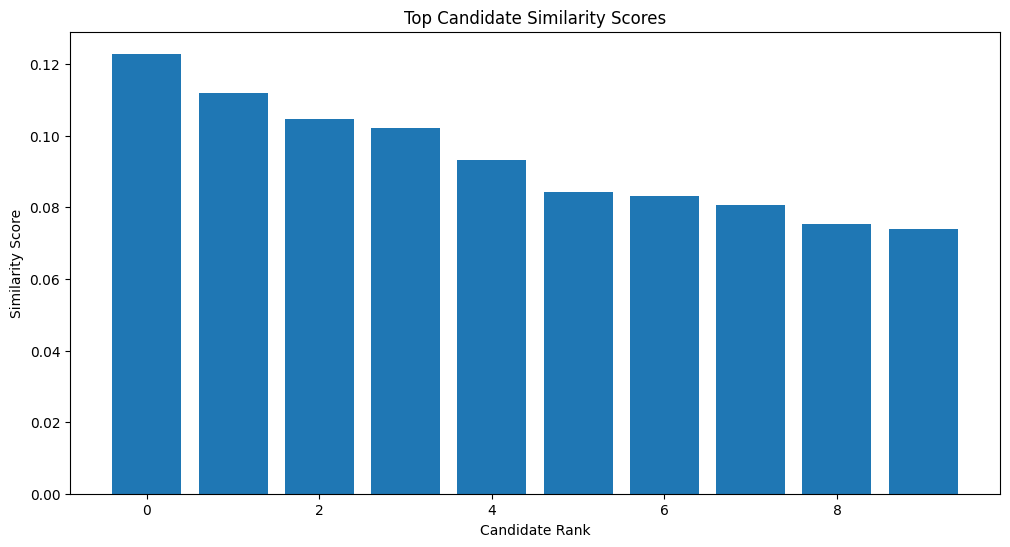

In [28]:
top_candidates = ranked_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(range(len(top_candidates)), top_candidates['score'])

plt.title("Top Candidate Similarity Scores")
plt.xlabel("Candidate Rank")
plt.ylabel("Similarity Score")

plt.show()

# Skill Extraction

Extracting important skills from resumes.

In [23]:
skills = [
    'python',
    'machine learning',
    'sql',
    'flask',
    'data analysis',
    'scikit-learn'
]

def extract_skills(text):
    
    found_skills = []
    
    for skill in skills:
        if skill in text.lower():
            found_skills.append(skill)
    
    return found_skills

df['skills'] = df['resume'].apply(extract_skills)

df[['skills']].head()

,skills
0,[data analysis]
1,[]
2,[]
3,[]
4,[]


# Top Candidates

Displaying top-ranked resumes with extracted skills.

In [27]:
ranked_df = df.sort_values(by='score', ascending=False)

top_results = ranked_df[['category', 'score', 'skills']].head(5)

print("Top Ranked Candidates:\n")

print(top_results)

Top Ranked Candidates:

         category     score                                          skills
926   AGRICULTURE  0.122916              [python, sql, flask, scikit-learn]
1339   AUTOMOBILE  0.112075                    [python, sql, data analysis]
1218   CONSULTANT  0.104718  [python, machine learning, sql, data analysis]
1762  ENGINEERING  0.102276  [python, machine learning, sql, data analysis]
1142   CONSULTANT  0.093171                                           [sql]


# Business Insights

- Resume screening saves recruiter time.
- Candidate ranking helps identify the best applicants quickly.
- Skill extraction improves hiring decisions.
- Automated screening reduces manual effort.

# Conclusion

This project successfully screens and ranks resumes using Natural Language Processing and Machine Learning.

The system compares resumes with job descriptions and ranks candidates based on similarity scores.

## Key Learnings
- NLP Preprocessing
- Resume Parsing
- TF-IDF Vectorization
- Cosine Similarity
- Skill Extraction
- Candidate Ranking